In [4]:
%pip install torch

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [3]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/validation.csv')
test_df = pd.read_csv('../data/processed/test.csv')

In [4]:
train_df = train_df[["review", "label"]]
val_df = val_df[["review", "label"]]
test_df = test_df[["review", "label"]]

In [5]:
# Convert to Hugging Face Datasets

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

In [6]:
MODEL_NAME = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [7]:
def tokenize(batch):
    return tokenizer(
        batch['review'],
        truncation=True,
        max_length=256
    )

In [8]:
train_tokenized = train_dataset.map(tokenize, batched=True)
val_tokenized = val_dataset.map(tokenize, batched=True)
test_tokenized = test_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 5000/5000 [00:00<00:00, 9212.67 examples/s]


In [9]:
id2label = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

label2id = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7285.83it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# evaluation metrics

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    
    precision, recall, f1, _ = (precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0))
    
    accuracy = accuracy_score(labels, predictions)
    
    return {
        "accuracy" : accuracy,
        "precision" : precision,
        "recall" : recall,
        "f1" : f1 
    }

In [12]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No GPU detected.")
    print("Training will run on CPU.")

No GPU detected.
Training will run on CPU.


In [13]:
TRAIN_SIZE = 6000
VAL_SIZE = 1500
TEST_SIZE = 1500

train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")
test_df = pd.read_csv("../data/processed/test.csv")

In [14]:
train_df = train_df.sample(
    n=TRAIN_SIZE,
    random_state=42
)

val_df = val_df.sample(
    n=VAL_SIZE,
    random_state=42
)

test_df = test_df.sample(
    n=TEST_SIZE,
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6000
Validation: 1500
Test: 1500


In [15]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["review", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["review", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["review", "label"]],
    preserve_index=False
)

In [16]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [17]:
def tokenize(batch):

    return tokenizer(
        batch["review"],
        truncation=True,
        max_length=128
    )

In [18]:
train_tokenized = train_dataset.map(
    tokenize,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize,
    batched=True
)

Map: 100%|██████████| 1500/1500 [00:00<00:00, 8310.02 examples/s]


In [19]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [20]:
id2label = {
    0: "NEGATIVE",
    1: "NEUTRAL",
    2: "POSITIVE"
}

label2id = {
    "NEGATIVE": 0,
    "NEUTRAL": 1,
    "POSITIVE": 2
}

In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2303.71it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [23]:
from transformers import TrainingArguments

In [24]:
training_args = TrainingArguments(
    output_dir='../models/checkpoints',
    
    per_device_train_batch_size = 4,
    per_device_eval_batch_size = 4,
    
    num_train_epochs=3,
    learning_rate= 2e-5,
    weight_decay=0.01,
    
    # Evaluation
    eval_strategy='epoch',
    
    # Save model after each epoch
    save_strategy='epoch',
    
    # Keep best model
    load_best_model_at_end=True,
    
    metric_for_best_model='f1',
    
    # Reduce logging overhead
    logging_steps=100,
    
    fp16=False,
    
    report_to='none'
)

In [25]:
from transformers import Trainer

In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [27]:
print("Model:", MODEL_NAME)
print("Device:", device)
print("Training examples:", len(train_tokenized))
print("Validation examples:", len(val_tokenized))
print("Test examples:", len(test_tokenized))

Model: distilbert/distilbert-base-uncased
Device: cpu
Training examples: 6000
Validation examples: 1500
Test examples: 1500


In [19]:
trainer.train()

e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.559161,0.595103,0.798667,0.786522,0.798667,0.788943
2,0.504970,0.714089,0.800000,0.800695,0.800000,0.800013
3,0.348071,0.863281,0.797333,0.803123,0.797333,0.799799


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]
e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.31s/it]
e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]


TrainOutput(global_step=4500, training_loss=0.47794403754340276, metrics={'train_runtime': 7231.9652, 'train_samples_per_second': 2.489, 'train_steps_per_second': 0.622, 'total_flos': 563819245758360.0, 'train_loss': 0.47794403754340276, 'epoch': 3.0})

In [20]:
results = trainer.evaluate(test_tokenized)


e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.348071,0.755314,3,0.798000,0.795777,0.798000,0.795438


In [28]:
from sklearn.metrics import classification_report

In [29]:
predictions = trainer.predict(test_tokenized)

e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [30]:
pred_labels  = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print(classification_report(true_labels, pred_labels, target_names=['Negative','Neutral','Positive']))

              precision    recall  f1-score   support

    Negative       0.39      0.79      0.52       570
     Neutral       0.00      0.00      0.00       330
    Positive       0.46      0.26      0.33       600

    accuracy                           0.41      1500
   macro avg       0.28      0.35      0.29      1500
weighted avg       0.33      0.41      0.33      1500



e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [31]:
# Confusion matrix

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

In [33]:
import matplotlib.pyplot as plt

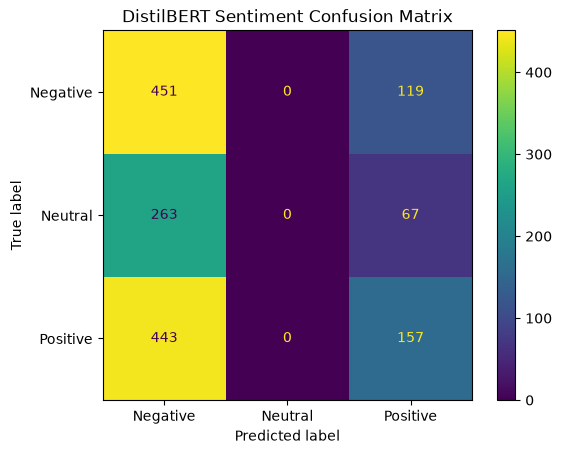

In [35]:
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    pred_labels,
    display_labels=['Negative','Neutral','Positive']
)

plt.title('DistilBERT Sentiment Confusion Matrix')

plt.show()

In [36]:
plt.savefig('../assets/confusion_matrix.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [37]:
# Saving trained model

In [38]:
MODEL_PATH ='../models/distilbert_sentiment_model'

trainer.save_model(MODEL_PATH)

tokenizer.save_pretrained(MODEL_PATH)

Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.49s/it]


('../models/distilbert_sentiment_model\\tokenizer_config.json',
 '../models/distilbert_sentiment_model\\tokenizer.json')

In [39]:
# Test inference on CPU

In [40]:
from transformers import pipeline

In [41]:
classifier = pipeline(
    'text-classification',
    model = MODEL_PATH,
    tokenizer = MODEL_PATH,
    device = -1
    
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2000.10it/s]


In [42]:
classifier("The camera quality is excellent")

[{'label': 'NEGATIVE', 'score': 0.3643753230571747}]

In [43]:
classifier(
    "The battery life is terrible."
)

[{'label': 'NEGATIVE', 'score': 0.3666056990623474}]

In [45]:
classifier("The camera is amazing.")

[{'label': 'NEGATIVE', 'score': 0.36395037174224854}]

In [46]:
test_sentences = [
    "This product is absolutely fantastic. I love it.",
    "This product is terrible. I hate it.",
    "The quality is okay, nothing special.",
    "Amazing product, excellent quality and very useful.",
    "Worst purchase ever. Completely disappointing."
]

for text in test_sentences:
    result = classifier(text)
    print(text)
    print(result)
    print()

This product is absolutely fantastic. I love it.
[{'label': 'NEGATIVE', 'score': 0.3604302704334259}]

This product is terrible. I hate it.
[{'label': 'NEGATIVE', 'score': 0.3655135929584503}]

The quality is okay, nothing special.
[{'label': 'NEGATIVE', 'score': 0.371275395154953}]

Amazing product, excellent quality and very useful.
[{'label': 'NEGATIVE', 'score': 0.36799386143684387}]

Worst purchase ever. Completely disappointing.
[{'label': 'NEGATIVE', 'score': 0.36461231112480164}]



In [47]:
for text in test_sentences:

    result = classifier(text)[0]

    print(
        f"{result['label']:10s} "
        f"{result['score']:.4f} | "
        f"{text}"
    )

NEGATIVE   0.3604 | This product is absolutely fantastic. I love it.
NEGATIVE   0.3655 | This product is terrible. I hate it.
NEGATIVE   0.3713 | The quality is okay, nothing special.
NEGATIVE   0.3680 | Amazing product, excellent quality and very useful.
NEGATIVE   0.3646 | Worst purchase ever. Completely disappointing.


In [48]:
print(model.config.id2label)
print(model.config.label2id)

{0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
{'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}


In [49]:
print(train_df["label"].value_counts().sort_index())

label
0    2381
1    1220
2    2399
Name: count, dtype: int64


In [50]:
print(train_df["label"].value_counts(normalize=True).sort_index())

label
0    0.396833
1    0.203333
2    0.399833
Name: proportion, dtype: float64


In [51]:
print(trainer.state.log_history)

[]


In [52]:
print("Train:", len(train_tokenized))
print("Validation:", len(val_tokenized))
print("Test:", len(test_tokenized))

Train: 6000
Validation: 1500
Test: 1500


In [53]:
print(train_tokenized[0])

{'review': "not bad. I tried this product hoping it will be similar to starbuck's white mocha..<br />unfortunately its only (sweet) .. no flavor of white mocha at all..<br />I had to made my own mix to have a nice one, where I add coffee & caramel sauce..<br />it tastes good with this mix..", 'label': 2, 'input_ids': [101, 2025, 2919, 1012, 1045, 2699, 2023, 4031, 5327, 2009, 2097, 2022, 2714, 2000, 2732, 24204, 1005, 1055, 2317, 9587, 7507, 1012, 1012, 1026, 7987, 1013, 1028, 6854, 2049, 2069, 1006, 4086, 1007, 1012, 1012, 2053, 14894, 1997, 2317, 9587, 7507, 2012, 2035, 1012, 1012, 1026, 7987, 1013, 1028, 1045, 2018, 2000, 2081, 2026, 2219, 4666, 2000, 2031, 1037, 3835, 2028, 1010, 2073, 1045, 5587, 4157, 1004, 14418, 10199, 12901, 1012, 1012, 1026, 7987, 1013, 1028, 2009, 16958, 2204, 2007, 2023, 4666, 1012, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [54]:
print(trainer.args.device)
print(trainer.args.per_device_train_batch_size)
print(trainer.args.num_train_epochs)

cpu
4
3


In [55]:
import re

def clean_text(text):
    text = str(text)

    # Remove HTML tags such as <br />
    text = re.sub(r"<.*?>", " ", text)

    # Remove repeated whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [56]:
train_df["review"] = train_df["review"].apply(clean_text)
val_df["review"] = val_df["review"].apply(clean_text)
test_df["review"] = test_df["review"].apply(clean_text)

In [57]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../models/checkpoints",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=1,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_steps=100,

    fp16=False,

    report_to="none"
)

In [58]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [59]:
trainer.train()


e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.492350,0.588730,0.792000,0.786116,0.792000,0.788619


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]


TrainOutput(global_step=1500, training_loss=0.6182555465698242, metrics={'train_runtime': 2354.6264, 'train_samples_per_second': 2.548, 'train_steps_per_second': 0.637, 'total_flos': 187904216332512.0, 'train_loss': 0.6182555465698242, 'epoch': 1.0})

In [60]:
print(trainer.state.log_history)

[{'loss': 0.9601111602783203, 'grad_norm': 11.803930282592773, 'learning_rate': 1.8680000000000004e-05, 'epoch': 0.06666666666666667, 'step': 100}, {'loss': 0.7101213836669922, 'grad_norm': 9.808591842651367, 'learning_rate': 1.7346666666666668e-05, 'epoch': 0.13333333333333333, 'step': 200}, {'loss': 0.5945273590087891, 'grad_norm': 8.068917274475098, 'learning_rate': 1.6013333333333335e-05, 'epoch': 0.2, 'step': 300}, {'loss': 0.6355467224121094, 'grad_norm': 2.1536290645599365, 'learning_rate': 1.4680000000000002e-05, 'epoch': 0.26666666666666666, 'step': 400}, {'loss': 0.558658447265625, 'grad_norm': 21.68236541748047, 'learning_rate': 1.3346666666666667e-05, 'epoch': 0.3333333333333333, 'step': 500}, {'loss': 0.6587686920166016, 'grad_norm': 1.5241678953170776, 'learning_rate': 1.2013333333333334e-05, 'epoch': 0.4, 'step': 600}, {'loss': 0.6389908599853515, 'grad_norm': 8.888433456420898, 'learning_rate': 1.0680000000000001e-05, 'epoch': 0.4666666666666667, 'step': 700}, {'loss': 

In [61]:
predictions = trainer.predict(test_tokenized)

pred_labels = np.argmax(
    predictions.predictions,
    axis=-1
)

true_labels = predictions.label_ids

e:\Gen Ai Course\Projects\ML Project\product-review-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [62]:
print("Predicted distribution:")
print(
    pd.Series(pred_labels)
    .value_counts()
    .sort_index()
)

print("\nActual distribution:")
print(
    pd.Series(true_labels)
    .value_counts()
    .sort_index()
)

Predicted distribution:
0    635
1    248
2    617
Name: count, dtype: int64

Actual distribution:
0    570
1    330
2    600
Name: count, dtype: int64


In [63]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.78      0.87      0.82       570
     Neutral       0.63      0.47      0.54       330
    Positive       0.87      0.89      0.88       600

    accuracy                           0.79      1500
   macro avg       0.76      0.74      0.75      1500
weighted avg       0.78      0.79      0.78      1500



In [64]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=-1
)

In [65]:
test_sentences = [
    "This product is absolutely fantastic. I love it.",
    "This product is terrible. I hate it.",
    "The quality is okay, nothing special.",
    "Amazing product, excellent quality and very useful.",
    "Worst purchase ever. Completely disappointing."
]

for text in test_sentences:

    result = classifier(text)[0]

    print(
        f"{result['label']:10s} "
        f"{result['score']:.4f} | "
        f"{text}"
    )

POSITIVE   0.9938 | This product is absolutely fantastic. I love it.
NEGATIVE   0.9838 | This product is terrible. I hate it.
NEUTRAL    0.8867 | The quality is okay, nothing special.
POSITIVE   0.9928 | Amazing product, excellent quality and very useful.
NEGATIVE   0.9843 | Worst purchase ever. Completely disappointing.


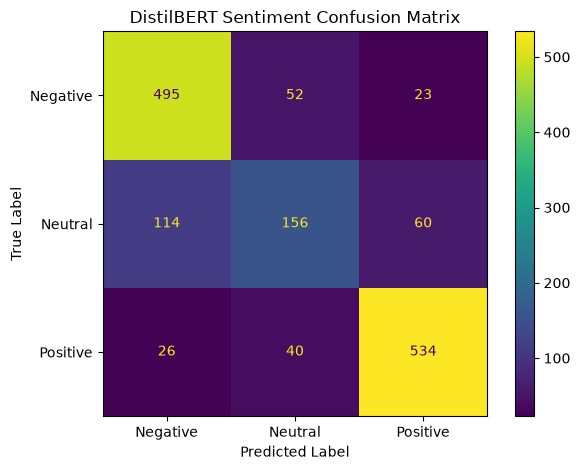

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    pred_labels,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    normalize=None
)

plt.title("DistilBERT Sentiment Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.show()

In [68]:
plt.savefig(
    "../assets/confusion_matrix_dev.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [69]:
DEV_MODEL_PATH = '../models/distilbert-sentiment-dev'

trainer.save_model(DEV_MODEL_PATH)
tokenizer.save_pretrained(DEV_MODEL_PATH)

print('Development model saved to:', DEV_MODEL_PATH)

Writing model shards: 100%|██████████| 1/1 [00:10<00:00, 10.52s/it]


Development model saved to: ../models/distilbert-sentiment-dev


In [70]:
dev_results = {
    'model': 'DistilBERT',
    'training_examples': 6000,
    'validation_examples': 1500,
    'test_examples': 1500,
    'epochs': 1,
    'max_length': 128,
    'batch_size': 4,
    'accuracy': 0.792,
    'weighted_f1': 0.7886,
    'macro_f1': 0.75
}



In [71]:
dev_results

{'model': 'DistilBERT',
 'training_examples': 6000,
 'validation_examples': 1500,
 'test_examples': 1500,
 'epochs': 1,
 'max_length': 128,
 'batch_size': 4,
 'accuracy': 0.792,
 'weighted_f1': 0.7886,
 'macro_f1': 0.75}

In [72]:
import re

def clean_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [73]:
for df in [train_df, val_df, test_df]:

    df["review"] = df["review"].apply(clean_text)

In [74]:
print(train_df["review"].iloc[0])

not bad. I tried this product hoping it will be similar to starbuck's white mocha.. unfortunately its only (sweet) .. no flavor of white mocha at all.. I had to made my own mix to have a nice one, where I add coffee & caramel sauce.. it tastes good with this mix..


In [75]:
train_df.to_csv(
    "../data/processed/train_clean.csv",
    index=False
)

val_df.to_csv(
    "../data/processed/validation_clean.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test_clean.csv",
    index=False
)